# Electrical Resistivity Tomography Visualization

This notebook presents a Python workflow for visualizing two-dimensional electrical
resistivity tomography (ERT) inversion models exported from RES2DINV.

The field survey consisted of two approximately perpendicular ERT profiles. Day 1 used
4 m electrode spacing and Day 2 used 3 m electrode spacing. Wenner and dipole-dipole
arrays were inverted for both profiles.

The workflow in this notebook:

1. loads the exported inversion models and electrode elevations;
2. summarizes survey geometry and resistivity ranges;
3. evaluates the resistivity distribution used to choose a common display scale;
4. prepares topography where the available elevation coordinates are compatible; and
5. compares the four inversion models using a consistent logarithmic resistivity scale.

The plotting and processing logic is implemented in reusable modules under `src/`.


## 1. Imports and project paths

The notebook imports reusable I/O, processing, and plotting functions from the
`ert_visualization` package. Project paths are defined relative to the repository root so
that the notebook works when launched either from the project root or from `notebooks/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from ert_visualization.io import (
    read_electrode_elevations,
    read_ert_xyz,
)
from ert_visualization.processing import (
    add_topography_to_model,
)
from ert_visualization.plotting import (
    plot_ert_comparison,
    plot_ert_topography_comparison,
    plot_ert_topography_section,
)

from ert_visualization.interactive import (
    make_ert_fence_diagram,
)


if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
FIGURE_DIR = PROJECT_ROOT / "figures"
INTERACTIVE_DIR = PROJECT_ROOT / "interactive"

FIGURE_DIR.mkdir(exist_ok=True)
INTERACTIVE_DIR.mkdir(exist_ok=True)

DISPLAY_VMIN = 1.0
DISPLAY_VMAX = 10_000.0


## 2. Load ERT and elevation data

The four inversion models are stored as RES2DINV-style `.xyz` files. Electrode elevations
are stored separately and divided into Day 1 and Day 2 profiles.


In [2]:
survey_files = {
    "Wenner Day 1": RAW_DATA_DIR / "Wenner_Day1.xyz",
    "Dipole-Dipole Day 1": RAW_DATA_DIR / "Dipole_Dipole_Day1.xyz",
    "Wenner Day 2": RAW_DATA_DIR / "Wenner_Day2.xyz",
    "Dipole-Dipole Day 2": RAW_DATA_DIR / "Dipole_Dipole_Day2.xyz",
}

ert_data = {
    survey_name: read_ert_xyz(filepath)
    for survey_name, filepath in survey_files.items()
}

elevation_data = read_electrode_elevations(
    DATA_DIR / "electrode_elevations.csv"
)

day1_elevation = elevation_data[
    elevation_data["line"] == "Day1"
].copy()

day2_elevation = elevation_data[
    elevation_data["line"] == "Day2"
].copy()


## 3. Dataset summary and geometry checks

Before plotting, the inversion models are summarized to confirm the number of model
blocks, horizontal extent, maximum model depth, and resistivity range.


In [3]:
survey_summary = pd.DataFrame(
    [
        {
            "Survey": survey_name,
            "Model blocks": len(df),
            "Profile start (m)": df["x_m"].min(),
            "Profile end (m)": df["x_m"].max(),
            "Maximum depth (m)": df["depth_positive_m"].max(),
            "Minimum resistivity (Ω·m)": df["resistivity_ohm_m"].min(),
            "Maximum resistivity (Ω·m)": df["resistivity_ohm_m"].max(),
        }
        for survey_name, df in ert_data.items()
    ]
)

survey_summary


,Survey,Model blocks,Profile start (m),Profile end (m),Maximum depth (m),Minimum resistivity (Ω·m),Maximum resistivity (Ω·m)
0,Wenner Day 1,748,6.0,314.0,52.50,5.45,35794.0
1,Dipole-Dipole Day 1,977,6.0,394.0,45.91,0.62,1327537.0
2,Wenner Day 2,644,4.5,229.5,29.94,1.96,156818.0
3,Dipole-Dipole Day 2,727,4.5,235.5,34.43,0.55,293065.0


In [4]:
elevation_summary = pd.DataFrame(
    [
        {
            "Profile": "Day 1",
            "Elevation start (m)": day1_elevation["x_m"].min(),
            "Elevation end (m)": day1_elevation["x_m"].max(),
            "Electrodes": len(day1_elevation),
        },
        {
            "Profile": "Day 2",
            "Elevation start (m)": day2_elevation["x_m"].min(),
            "Elevation end (m)": day2_elevation["x_m"].max(),
            "Electrodes": len(day2_elevation),
        },
    ]
)

elevation_summary


,Profile,Elevation start (m),Elevation end (m),Electrodes
0,Day 1,0,320,81
1,Day 2,0,240,81


### Survey geometry note

Day 1 and Day 2 were collected along approximately perpendicular profiles with different
electrode spacing.

The available Day 1 elevation profile spans 0–320 m, while the Dipole-Dipole Day 1
inversion model extends to approximately 394 m. Because those horizontal coordinates do
not directly match, topographic correction is **not** applied to the Dipole-Dipole Day 1
model until the coordinate relationship can be verified.

The uncorrected depth-coordinate comparison remains valid because it uses each inversion
model in its native horizontal and depth coordinates.


## 4. Resistivity distribution and display scale

The inversion models contain resistivity values spanning several orders of magnitude.
Using the absolute minimum and maximum values for the colour scale would allow a small
number of extreme values to dominate the visualization.

A common display range of **1–10,000 Ω·m** is used for comparison. The following
diagnostics show the fraction of model blocks below, within, and above that range and the
resistivity percentiles for each survey.


In [5]:
scale_summary = []

for survey_name, df in ert_data.items():
    resistivity = df["resistivity_ohm_m"]

    below = (resistivity < DISPLAY_VMIN).sum()
    within = (
        (resistivity >= DISPLAY_VMIN)
        & (resistivity <= DISPLAY_VMAX)
    ).sum()
    above = (resistivity > DISPLAY_VMAX).sum()
    total = len(resistivity)

    scale_summary.append(
        {
            "Survey": survey_name,
            "Below scale (%)": 100 * below / total,
            "Within scale (%)": 100 * within / total,
            "Above scale (%)": 100 * above / total,
        }
    )

scale_summary = pd.DataFrame(scale_summary)
scale_summary.round(1)


,Survey,Below scale (%),Within scale (%),Above scale (%)
0,Wenner Day 1,0.0,98.9,1.1
1,Dipole-Dipole Day 1,0.1,98.6,1.3
2,Wenner Day 2,0.0,95.7,4.3
3,Dipole-Dipole Day 2,1.2,94.8,4.0


In [6]:
percentiles = [1, 2, 5, 25, 50, 75, 95, 98, 99]

percentile_summary = pd.DataFrame(
    {
        survey_name: {
            f"{percentile}%": np.percentile(
                df["resistivity_ohm_m"],
                percentile,
            )
            for percentile in percentiles
        }
        for survey_name, df in ert_data.items()
    }
).T

percentile_summary.round(2)


,1%,2%,5%,25%,50%,75%,95%,98%,99%
Wenner Day 1,7.77,9.96,16.66,21.16,26.77,36.57,202.71,2931.58,9717.12
Dipole-Dipole Day 1,3.63,5.80,10.04,20.84,27.50,38.39,144.64,4089.92,25856.88
Wenner Day 2,2.54,3.07,6.09,25.48,38.08,95.75,6885.85,22822.00,38139.18
Dipole-Dipole Day 2,0.95,2.68,8.77,26.20,35.51,57.90,5025.19,21378.68,85672.22


The distributions are strongly right-skewed, particularly in the Day 2 models. A shared
logarithmic display scale preserves comparison between surveys while preventing isolated
extreme inversion values from controlling the full colour range.

The model-block values are interpolated in `log10` resistivity space for visualization and
then converted back to Ω·m before plotting. This affects only the visualization between
exported model-block centres; it does not alter or repeat the original ERT inversion.


## 5. Prepare topographic models

Topography can be applied only where the measured elevation profile spans the complete
horizontal extent of the corresponding inversion model.

The current elevation data support Wenner Day 1 and both Day 2 inversions. Dipole-Dipole
Day 1 is intentionally excluded pending verification of its horizontal coordinate relationship.


In [7]:
topographic_models = {
    "Wenner Day 1": add_topography_to_model(
        ert_data["Wenner Day 1"],
        day1_elevation,
    ),
    "Wenner Day 2": add_topography_to_model(
        ert_data["Wenner Day 2"],
        day2_elevation,
    ),
    "Dipole-Dipole Day 2": add_topography_to_model(
        ert_data["Dipole-Dipole Day 2"],
        day2_elevation,
    ),
}

topographic_models["Wenner Day 1"][
    [
        "x_m",
        "depth_positive_m",
        "surface_elevation_m",
        "model_elevation_m",
    ]
].head()


,x_m,depth_positive_m,surface_elevation_m,model_elevation_m
0,6.0,1.0,1252.248820,1251.248820
1,10.0,1.0,1252.106825,1251.106825
2,14.0,1.0,1251.930560,1250.930560
3,18.0,1.0,1251.765620,1250.765620
4,22.0,1.0,1251.668640,1250.668640


## 6. Compare ERT inversion models

All four inversion models are displayed using the same **1–10,000 Ω·m logarithmic colour
scale** and `log10`-space interpolation. White regions fall outside the spatial support of
the exported inversion model and are intentionally left unfilled.


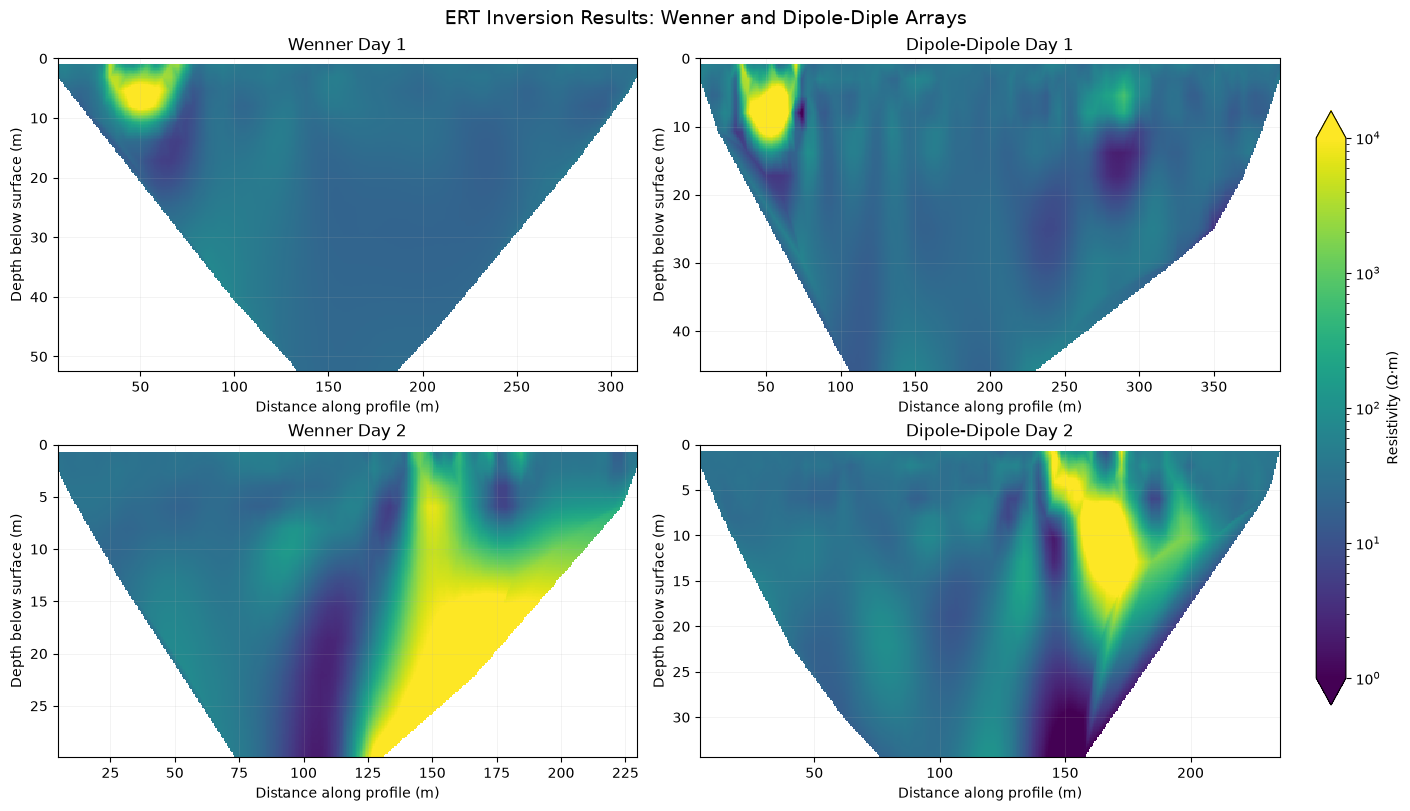

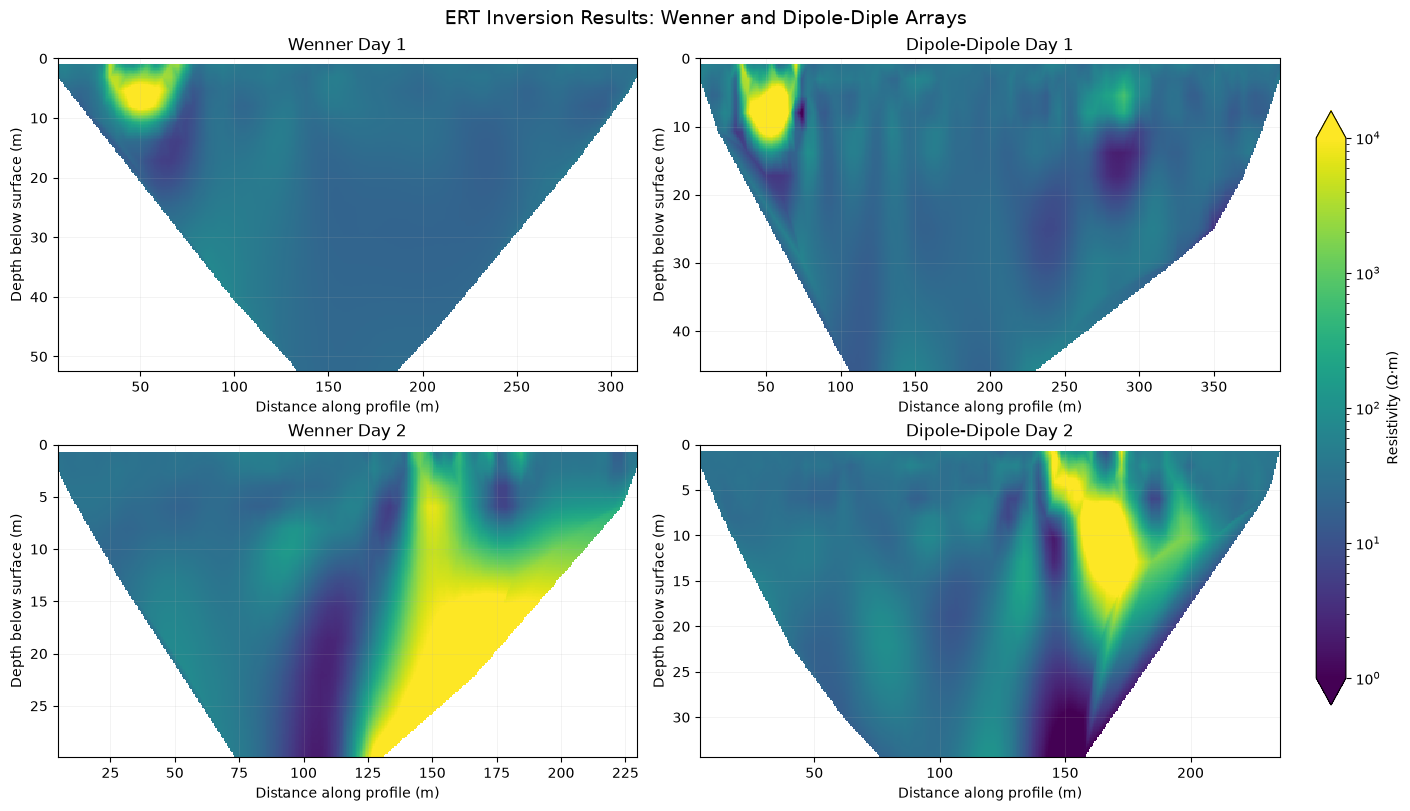

In [8]:
comparison_fig = plot_ert_comparison(
    ert_data,
    vmin=DISPLAY_VMIN,
    vmax=DISPLAY_VMAX,
    interpolation_space="log10",
)

comparison_fig.savefig(
    FIGURE_DIR / "ert_inversion_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

comparison_fig


## 7. Next steps

The next stage of the project will extend the reusable plotting tools to:

- plot inversion models relative to measured surface elevation;
- resolve the Dipole-Dipole Day 1 horizontal-coordinate mismatch before applying topography;
- add the approximate borehole location where justified by the survey geometry; and
- rebuild the interactive pseudo-3D fence diagram while clearly distinguishing it from a
  true 3-D resistivity inversion.


## 7. Topographic ERT sections

The inversion models can also be displayed relative to measured ground
elevation. This preserves the actual surface geometry rather than treating
the survey line as horizontal.

Topographic sections are produced only where the available electrode
elevations cover the complete horizontal extent of the inversion model.

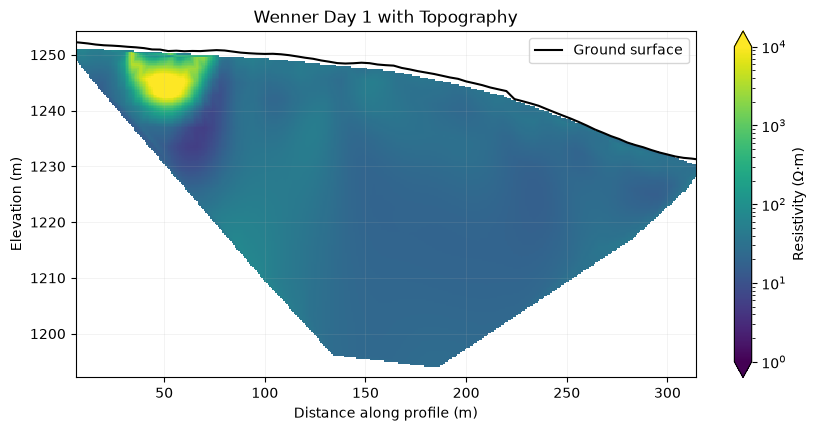

In [9]:
wenner_day1_topography_fig, ax, mesh = (
    plot_ert_topography_section(
        topographic_models["Wenner Day 1"],
        day1_elevation,
        title="Wenner Day 1 with Topography",
        vmin=DISPLAY_VMIN,
        vmax=DISPLAY_VMAX,
    )
)

colorbar = wenner_day1_topography_fig.colorbar(
    mesh,
    ax=ax,
    extend="both",
)

colorbar.set_label(
    "Resistivity (Ω·m)"
)

In [10]:
topographic_elevations = {
    "Wenner Day 1": day1_elevation,
    "Wenner Day 2": day2_elevation,
    "Dipole-Dipole Day 2": day2_elevation,
}

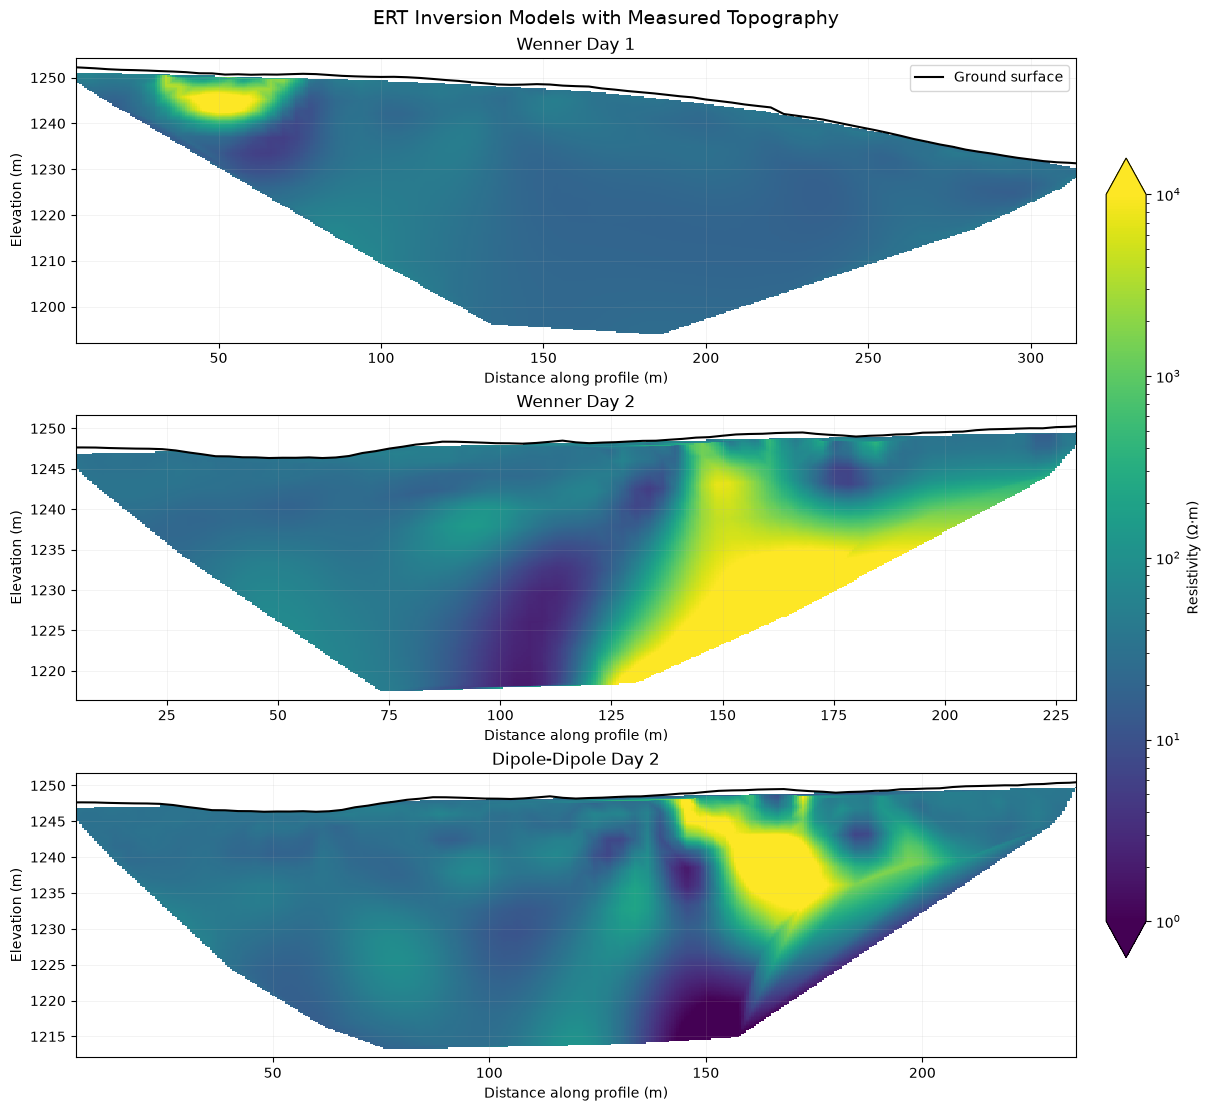

In [11]:
topography_comparison_fig = (
    plot_ert_topography_comparison(
        topographic_models,
        topographic_elevations,
        vmin=DISPLAY_VMIN,
        vmax=DISPLAY_VMAX,
    )
)

In [12]:
topography_comparison_fig.savefig(
    FIGURE_DIR / "ert_topography_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

In [13]:
dipole_day1_path = survey_files[
    "Dipole-Dipole Day 1"
]

with dipole_day1_path.open(
    "r",
    encoding="latin1",
) as file:
    dipole_day1_lines = file.readlines()

for line in dipole_day1_lines[:30]:
    print(line.rstrip())

/Name of survey line is Project2 Dipole-Dipole_1
/Number of blocks is 977
/The x and z coordinates of the centres of the model blocks, and
/The resistivity and conductivity of each block is given below.
/        X           Depth    Resistivity  Conductivity
        6.00        -1.00        46.47         0.0215
       10.00        -1.00        59.17         0.0169
       14.00        -1.00        47.79         0.0209
       18.00        -1.00        44.48         0.0225
       22.00        -1.00        44.38         0.0225
       26.00        -1.00        40.50         0.0247
       30.00        -1.00       141.22       0.007081
       34.00        -1.00      4916.90       0.000203
       38.00        -1.00       113.93       0.008777
       42.00        -1.00        73.06         0.0137
       46.00        -1.00        83.39         0.0120
       50.00        -1.00        67.72         0.0148
       54.00        -1.00       606.00       0.001650
       58.00        -1.00        31.02 

### Survey geometry note

Day 1 used 4 m electrode spacing and Day 2 used 3 m spacing. The exported
Dipole-Dipole Day 1 model also uses 4 m horizontal increments, but extends
to approximately 394 m, while the available measured Day 1 elevation
profile spans only 0–320 m.

Because the available project material does not document the reason for
this difference or provide topography beyond 320 m, the Dipole-Dipole
Day 1 model is retained in its native depth coordinates but is excluded
from topography-corrected figures. Its horizontal coordinates are not
rescaled or extrapolated.

## 8. Interactive pseudo-3D fence diagram

The Day 1 and Day 2 Wenner inversion models can be displayed as
approximately perpendicular vertical sections to illustrate their spatial
relationship.

Because the exact along-profile coordinates of the survey-line intersection
are not available in the current project files, the profiles are centered
on a schematic intersection for this visualization. The diagram therefore
shows the relationship between the two 2-D sections but does not represent
a surveyed 3-D model.

This fence diagram should not be interpreted as a true 3-D ERT inversion.

In [14]:
fence_fig = make_ert_fence_diagram(
    day1_model=topographic_models["Wenner Day 1"],
    day1_elevation=day1_elevation,
    day2_model=topographic_models["Wenner Day 2"],
    day2_elevation=day2_elevation,
    vmin=DISPLAY_VMIN,
    vmax=DISPLAY_VMAX,
)

fence_fig

In [15]:
fence_fig.write_html(
    INTERACTIVE_DIR / "ert_wenner_fence_diagram.html",
    include_plotlyjs="cdn",
)